<a href="https://colab.research.google.com/github/tu25003-7491-cyber/EU_M_Math-Repository/blob/main/Chap09_Ex_03_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

import sklearn

import requests
import io

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

データの形状: (569, 30)
目的変数の名前: ['malignant' 'benign']
説明変数の数: 30


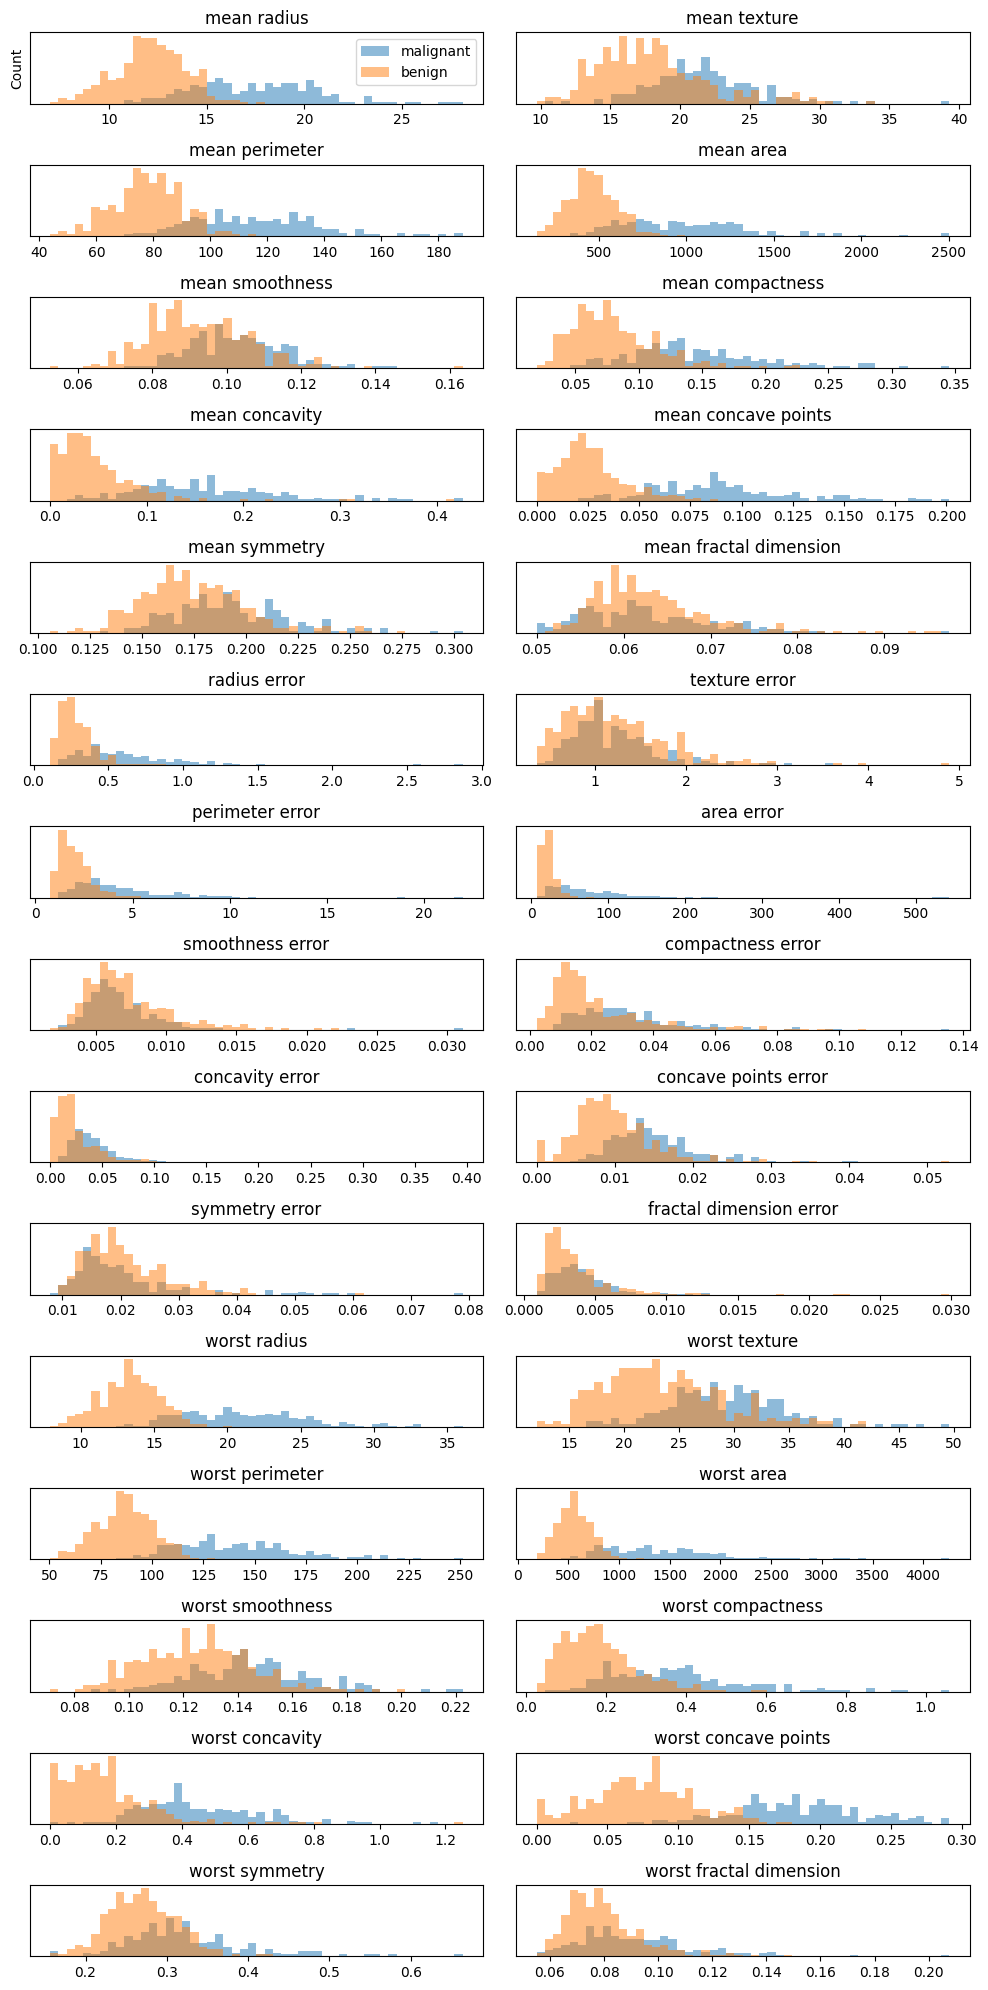

X_pca shape:(569, 2)
Explained variance ratio:[0.44272026 0.18971182]
第2主成分までの累積寄与率:0.632

主成分ベクトル
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
第1主成分     0.218902      0.103725        0.227537   0.220995         0.142590   
第2主成分    -0.233857     -0.059706       -0.215181  -0.231077         0.186113   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
第1主成分          0.239285        0.258400             0.260854       0.138167   
第2主成分          0.151892        0.060165            -0.034768       0.190349   

       mean fractal dimension  ...  worst radius  worst texture  \
第1主成分                0.064363  ...      0.227997       0.104469   
第2主成分                0.366575  ...     -0.219866      -0.045467   

       worst perimeter  worst area  worst smoothness  worst compactness  \
第1主成分         0.236640    0.224871          0.127953           0.210096   
第2主成分        -0.199878   -0.219352          0.172304           0.14359

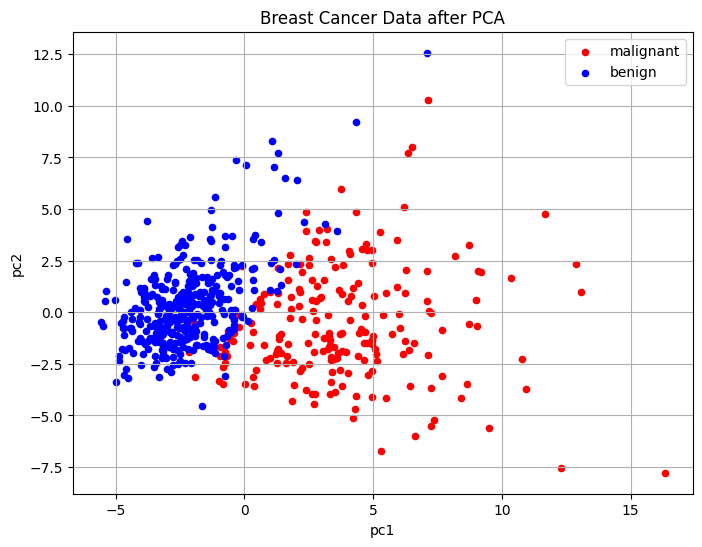

In [3]:
# 乳がんデータを読み込む
cancer = load_breast_cancer()

# データの確認
print('データの形状:', cancer.data.shape)
print('目的変数の名前:', cancer.target_names)
print('説明変数の数:', len(cancer.feature_names))

# 良性・悪性データを分ける
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]

# 各特徴量のヒストグラムを表示
fig, axes = plt.subplots(15, 2, figsize=(10, 20))
ax = axes.ravel()

for i in range(30):
    _, bins = np.histogram(cancer.data[:, i], bins=50)

    ax[i].hist(malignant[:, i], bins=bins, alpha=0.5)
    ax[i].hist(benign[:, i], bins=bins, alpha=0.5)

    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())

ax[0].set_ylabel('Count')
ax[0].legend(['malignant', 'benign'], loc='best')
fig.tight_layout()
plt.show()

# 標準化
sc = StandardScaler()
X_std = sc.fit_transform(cancer.data)

# 主成分分析
pca = PCA(n_components=2)
pca.fit(X_std)

# 主成分分析後のデータ
X_pca = pca.transform(X_std)

# 結果の確認
print('X_pca shape:{}'.format(X_pca.shape))
print('Explained variance ratio:{}'.format(pca.explained_variance_ratio_))
print('第2主成分までの累積寄与率:{:.3f}'.format(
    pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]
))

# 主成分と元の説明変数との関係を確認
components = DataFrame(
    pca.components_,
    columns=cancer.feature_names,
    index=['第1主成分', '第2主成分']
)

print('\n主成分ベクトル')
print(components)

# 主成分分析後のデータをDataFrameに変換
X_pca_df = DataFrame(X_pca, columns=['pc1', 'pc2'])

# 目的変数を結合
X_pca_df = pd.concat(
    [X_pca_df, DataFrame(cancer.target, columns=['target'])],
    axis=1
)

# 悪性、良性を分ける
pca_malignant = X_pca_df[X_pca_df['target'] == 0]
pca_benign = X_pca_df[X_pca_df['target'] == 1]

# 第1主成分と第2主成分をグラフ化
ax = pca_malignant.plot.scatter(
    x='pc1',
    y='pc2',
    color='red',
    label='malignant',
    figsize=(8, 6)
)

pca_benign.plot.scatter(
    x='pc1',
    y='pc2',
    color='blue',
    label='benign',
    ax=ax
)

plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('Breast Cancer Data after PCA')
plt.grid(True)
plt.show()